# **LOAN DEFAULT PREDICTION**

## **LOADING THE DATASET**

In [1]:
import pandas as pd
df = pd.read_csv('LoanData.csv')

## **OVERVIEWING THE DATA**

In [2]:
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  object 
 3   home_ownership       32586 non-null  object 
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  object 
 6   loan_grade           32586 non-null  object 
 7   loan_amnt            32585 non-null  object 
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11849 non-null  object 
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32582 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 3.2+ MB


In [4]:
df.describe()

,customer_id,customer_age,employment_duration,loan_int_rate,term_years,cred_hist_length
count,32583.000000,32586.000000,31691.000000,29470.000000,32586.000000,32586.000000
mean,16289.497806,27.732769,4.790161,11.011553,4.761738,5.804026
std,9405.919628,6.360528,4.142746,3.240440,2.471107,4.055078
min,1.000000,3.000000,0.000000,5.420000,1.000000,2.000000
25%,8144.500000,23.000000,2.000000,7.900000,3.000000,3.000000
50%,16288.000000,26.000000,4.000000,10.990000,4.000000,4.000000
75%,24433.500000,30.000000,7.000000,13.470000,7.000000,8.000000
max,32581.000000,144.000000,123.000000,23.220000,10.000000,30.000000


In [5]:
df.isnull().sum()

customer_id                3
customer_age               0
customer_income            0
home_ownership             0
employment_duration      895
loan_intent                0
loan_grade                 0
loan_amnt                  1
loan_int_rate           3116
term_years                 0
historical_default     20737
cred_hist_length           0
Current_loan_status        4
dtype: int64

## **DATA CLEANING**

In [6]:
#Drop Unnecessary Column
df.drop(['customer_id'],axis=1,inplace=True)

In [7]:
#Filling missing numerical values
df['employment_duration']=df['employment_duration'].fillna(df['employment_duration'].median())

In [8]:
#Changing objects to numeric
df['loan_amnt']=df['loan_amnt'].str.replace('£', '', regex=False).str.replace(',','',regex=False)
df['loan_amnt']=pd.to_numeric(df['loan_amnt'])

#Filling missing numerical values
df['loan_amnt']=df['loan_amnt'].fillna(df['loan_amnt'].median())

In [9]:
#Changing objects to numeric
df['customer_income']=df['customer_income'].str.replace(',','',regex=False)
df['customer_income']=pd.to_numeric(df['customer_income'])

In [10]:
#Filling missing numerical values using groupby and median
df['loan_int_rate']=df.groupby('loan_grade')['loan_int_rate'].transform(lambda x:x.fillna(x.median()))

In [11]:
#Filling missing values with new category 
df['historical_default']=df['historical_default'].fillna('Unknown')

In [12]:
#Checking for data imbalance in target variable
df['Current_loan_status'].value_counts()

Current_loan_status
NO DEFAULT    25742
DEFAULT        6840
Name: count, dtype: int64

In [13]:
df['historical_default'].value_counts()

historical_default
Unknown    20737
Y           6128
N           5721
Name: count, dtype: int64

In [14]:
#Dropping missing values of target variable( because they were less)
df = df.dropna(subset=['Current_loan_status'])

In [15]:
# Verify missing values are handled
df.isnull().sum()

customer_age           0
customer_income        0
home_ownership         0
employment_duration    0
loan_intent            0
loan_grade             0
loan_amnt              0
loan_int_rate          0
term_years             0
historical_default     0
cred_hist_length       0
Current_loan_status    0
dtype: int64

## **EXPLORATORY DATA ANALYSIS**

## **LOAN STATUS DISTRIBUTION**

In [16]:
#Importing Libraries for Visualization
import seaborn as sns
import matplotlib.pyplot as plt 

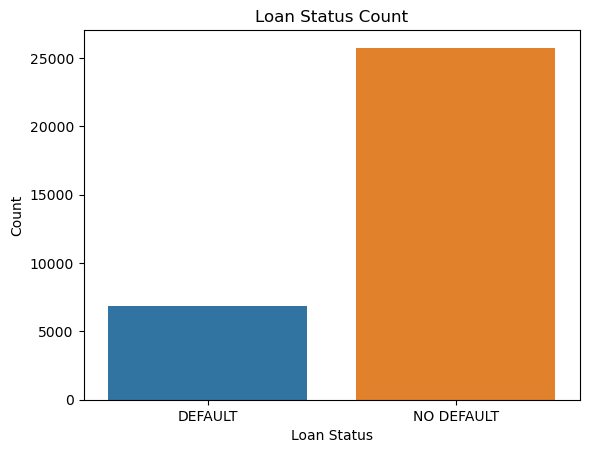

In [17]:
sns.countplot(x='Current_loan_status',data= df, hue = 'Current_loan_status')
plt.title('Loan Status Count')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

## **LOAN STATUS VS HISTORICAL DEFAULT**

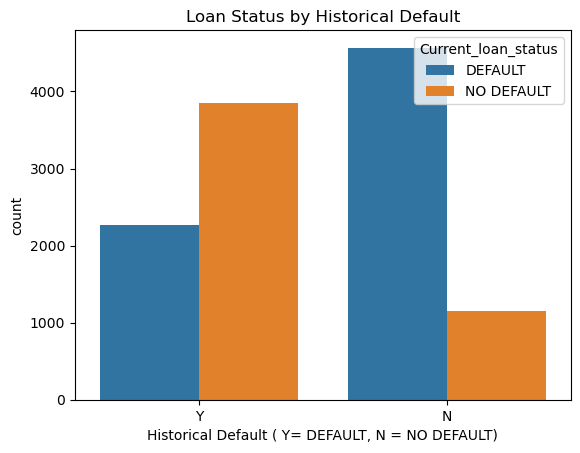

In [18]:
#Excluding the "Unknown Category" for better insights
df_plot = df[df['historical_default'] != 'Unknown']

#Plot
sns.countplot(x='historical_default', hue='Current_loan_status', data=df_plot)
plt.title('Loan Status by Historical Default')
plt.xlabel('Historical Default ( Y= DEFAULT, N = NO DEFAULT)')
plt.show()

## **DEFAULT RATE BY LOAN INTENT**

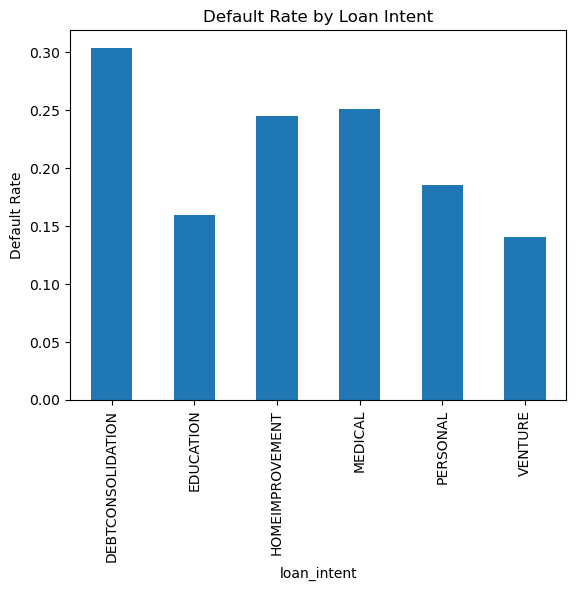

In [19]:
#Using groupby and mean  for calculating Default Rate 
temp = df.groupby('loan_intent')['Current_loan_status'].apply(lambda x: (x=='DEFAULT').mean())
temp.plot(kind='bar')

#Plot
plt.title('Default Rate by Loan Intent')
plt.ylabel('Default Rate')
plt.show()

## **DEFAULT RATE BY LOAN GRADE**

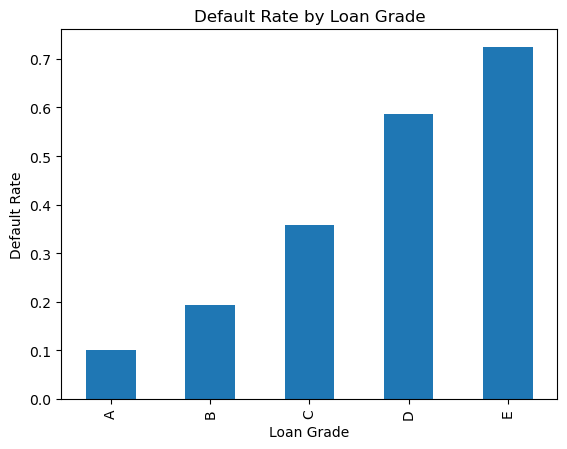

In [20]:
#Using groupby and mean  for calculating Default Rate 
temp = df.groupby('loan_grade')['Current_loan_status'].apply(lambda x: (x=='DEFAULT').mean())

#Plot
temp.plot(kind='bar')
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate')
plt.show()

## **INTEREST RATE VS DEFAULT**

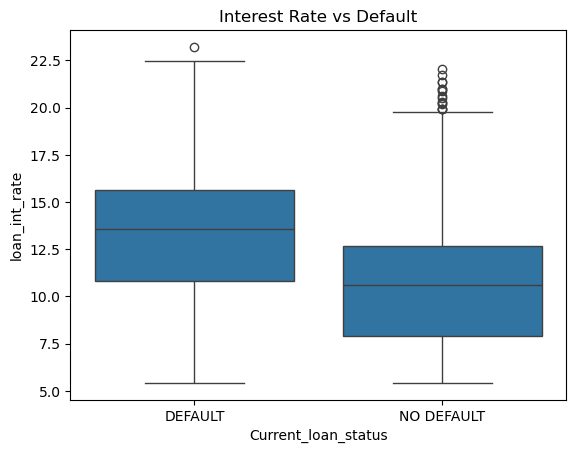

In [21]:
sns.boxplot(x='Current_loan_status', y='loan_int_rate', data=df)
plt.title('Interest Rate vs Default')
plt.show()

## **HOME OWNERSHIP VS DEFAULT**

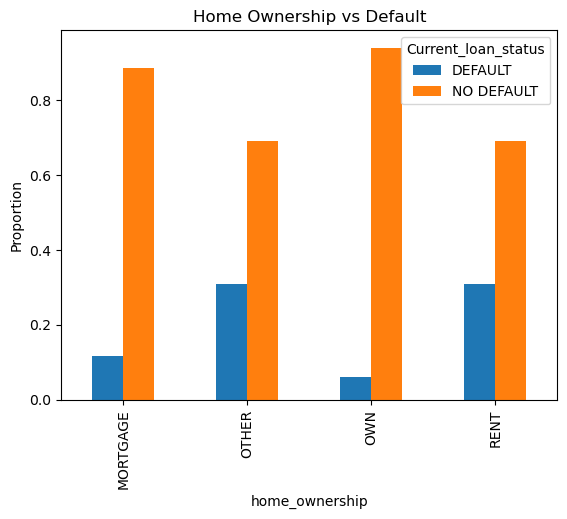

In [22]:
#Using crosstab for calculating the proportion
ct = pd.crosstab(
    df['home_ownership'],
    df['Current_loan_status'],
    normalize='index'
)

#Plot
ct.plot(kind='bar')
plt.title('Home Ownership vs Default')
plt.ylabel('Proportion')
plt.show()

## **DEAFULT RATE BY LOAN AMOUNT**

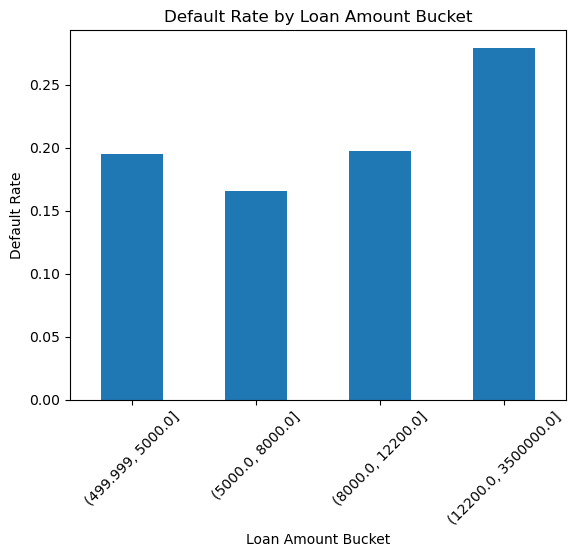

In [23]:
# Create buckets (quartiles)
df['loan_bucket'] = pd.qcut(df['loan_amnt'], 4)

# Calculate default rate
temp = df.groupby('loan_bucket', observed=False)['Current_loan_status']\
         .apply(lambda x: (x == 'DEFAULT').mean())

# Plot
temp.plot(kind='bar')
plt.title('Default Rate by Loan Amount Bucket')
plt.xlabel('Loan Amount Bucket')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.show()

## **INCOME VS DEFAULT STATUS**

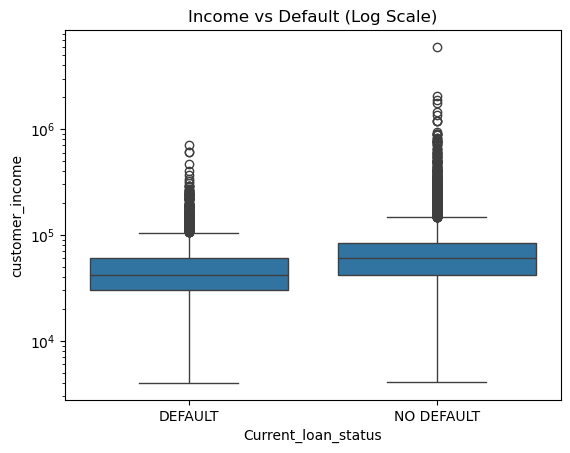

In [24]:
sns.boxplot(x='Current_loan_status', y='customer_income', data=df)
plt.yscale('log') 
plt.title('Income vs Default (Log Scale)')
plt.show()

## **CORRELATION HEATMAP**

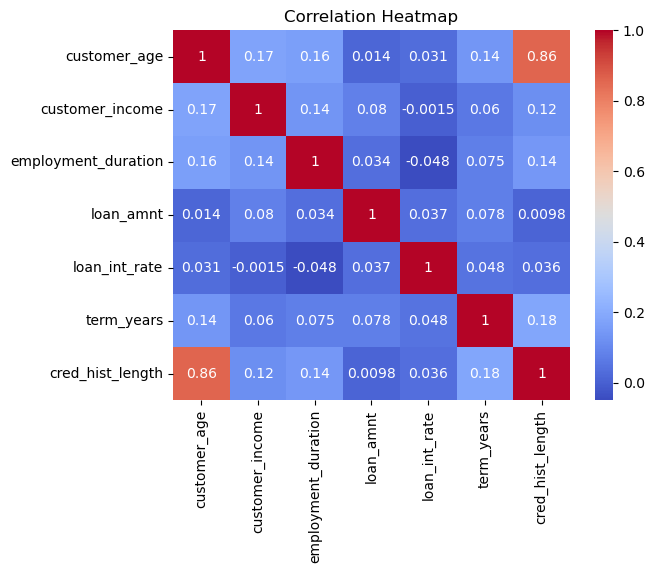

In [25]:
#inculding only numerical columns
num_df = df.select_dtypes(include=['int64','float64'])

#Plot
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## **ENCODE CATEGORICAL VARIABLE**

In [26]:
# One-hot
df = pd.get_dummies(df, columns=['home_ownership', 'loan_intent'], drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Ordinal
df['loan_grade'] = df['loan_grade'].map({'A':1, 'B':2, 'C':3, 'D':4, 'E':5})

# Binary
df['historical_default'] = df['historical_default'].map({'Y':1, 'N':0, 'Unknown':-1})
df['Current_loan_status'] = df['Current_loan_status'].map({'DEFAULT':1, 'NO DEFAULT':0})


In [27]:
#Dropping unnecessary column
df=df.drop(['loan_bucket'],axis=1)

In [28]:
#Checking data type 
df.dtypes

customer_age                     int64
customer_income                  int64
employment_duration            float64
loan_grade                       int64
loan_amnt                      float64
loan_int_rate                  float64
term_years                       int64
historical_default               int64
cred_hist_length                 int64
Current_loan_status              int64
home_ownership_OTHER             int64
home_ownership_OWN               int64
home_ownership_RENT              int64
loan_intent_EDUCATION            int64
loan_intent_HOMEIMPROVEMENT      int64
loan_intent_MEDICAL              int64
loan_intent_PERSONAL             int64
loan_intent_VENTURE              int64
dtype: object

## **SPLIT DATA INTO FEATURE AND TARGET**

In [29]:
#Target Variable
y=df['Current_loan_status']

#Features
X=df.drop('Current_loan_status', axis=1)

#Printing Shape
print(y.shape)
print(X.shape)

(32582,)
(32582, 17)


## **TRAINING MODEL**

In [30]:
#Splitting Data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

#Scaling Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Training Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000,class_weight='balanced',random_state=42)
model.fit(X_train_scaled, y_train)

#Predict
y_pred = model.predict(X_test_scaled)

#Evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8543808500843947
[[4371  779]
 [ 170 1197]]
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      5150
           1       0.61      0.88      0.72      1367

    accuracy                           0.85      6517
   macro avg       0.78      0.86      0.81      6517
weighted avg       0.89      0.85      0.86      6517



## **RANDOM FOREST CLASSIFIER MODEL**

In [31]:
#  Train Random Forest (regularized to avoid overfitting)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Check overfitting
print("\nTrain Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Test Accuracy: 0.9370876170016879

Confusion Matrix:
 [[4794  356]
 [  54 1313]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96      5150
           1       0.79      0.96      0.86      1367

    accuracy                           0.94      6517
   macro avg       0.89      0.95      0.91      6517
weighted avg       0.95      0.94      0.94      6517


Train Accuracy: 0.9485900633032802
Test Accuracy: 0.9370876170016879


## **FEATURE IMPORTANCE**

historical_default     0.612756
loan_int_rate          0.088191
customer_income        0.078303
loan_grade             0.062355
home_ownership_RENT    0.040140
loan_amnt              0.027035
customer_age           0.022619
cred_hist_length       0.022235
home_ownership_OWN     0.012148
employment_duration    0.009095
dtype: float64


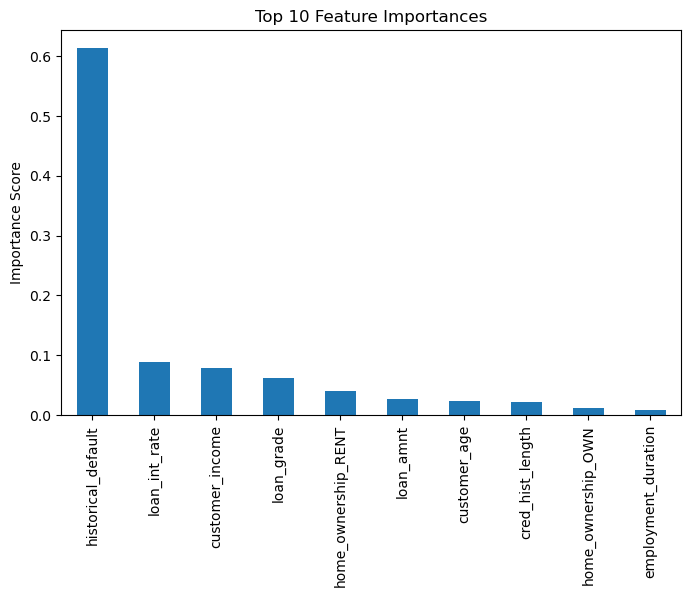

In [32]:
# Get importance
importance = pd.Series(rf.feature_importances_, index=X.columns)

# Sort
importance = importance.sort_values(ascending=False)

# Print top features
print(importance.head(10))

# Plot
plt.figure(figsize=(8,5))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances')
plt.ylabel('Importance Score')
plt.show()